**Import necessery Dependencies**

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.head()

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless_Billing  7043 

  

*    Drop CustomerID columns as it's not necessory for prediction
*   Convert Total_Charges into float64



In [8]:
df = df.drop(columns=["customerID"])

In [18]:
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   Senior_Citizen     7043 non-null   int64  
 2   Is_Married         7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   tenure             7043 non-null   int64  
 5   Phone_Service      7043 non-null   object 
 6   Dual               7043 non-null   object 
 7   Internet_Service   7043 non-null   object 
 8   Online_Security    7043 non-null   object 
 9   Online_Backup      7043 non-null   object 
 10  Device_Protection  7043 non-null   object 
 11  Tech_Support       7043 non-null   object 
 12  Streaming_TV       7043 non-null   object 
 13  Streaming_Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless_Billing  7043 non-null   object 
 16  Payment_Method     7043 

In [20]:
df.head()

,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
print(df.isnull().sum())

gender               0
Senior_Citizen       0
Is_Married           0
Dependents           0
tenure               0
Phone_Service        0
Dual                 0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
Churn                0
dtype: int64




*   There's No missing values



In [22]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64



*   Class imbalance founded in Churn column




**EDA**

In [23]:
df.shape

(7043, 20)

In [24]:
df.columns

Index(['gender', 'Senior_Citizen ', 'Is_Married', 'Dependents', 'tenure',
       'Phone_Service', 'Dual', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

In [25]:
df.head()

,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.describe()

,Senior_Citizen,tenure,Monthly_Charges,Total_Charges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000




*   There's a skewness here in the numerical columns
*   Tenure is moderate the mean&median is close to each other
*   Monthly_Charges is skewed to left because median > mean
*   Total_Charges is skewed to right because mean > median
*   Visualization will make it more insightfully!
*   There's 11 missing values in Total_Charges column!



**Visualization**

1.   Numerical Features










In [27]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  column_mean = df[column_name].mean()
  column_median = df[column_name].median()

  plt.axvline(column_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(column_median, color="green", linestyle="-", label="Median")

  plt.legend()
  plt.show()

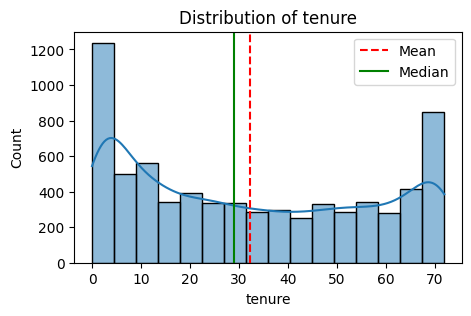

In [28]:
plot_histogram(df, "tenure")

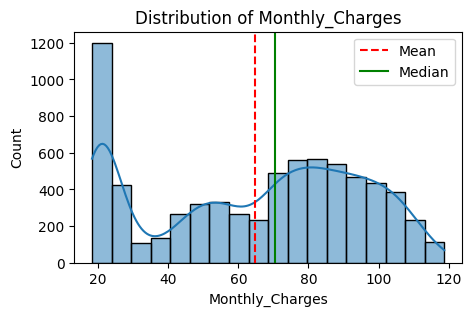

In [30]:
plot_histogram(df, "Monthly_Charges")

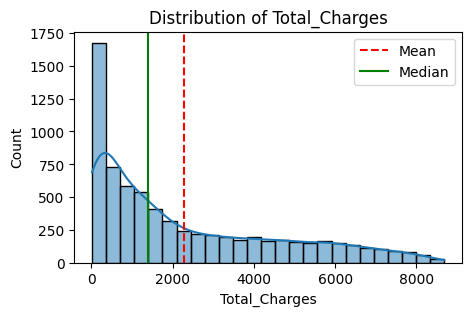

In [31]:
plot_histogram(df, "Total_Charges")

In [32]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show

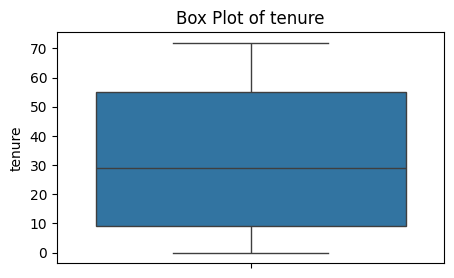

In [33]:
plot_boxplot(df, "tenure")

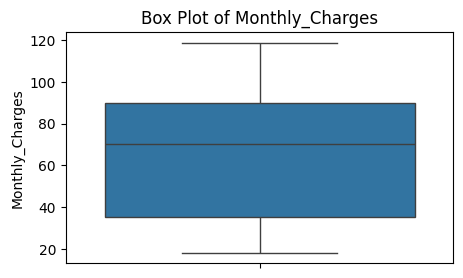

In [34]:
plot_boxplot(df, "Monthly_Charges")

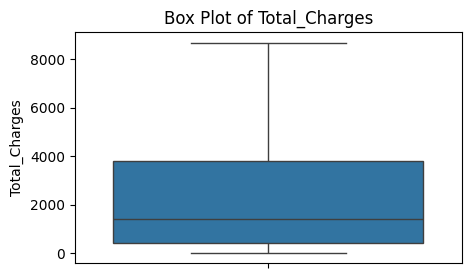

In [35]:
plot_boxplot(df, "Total_Charges")

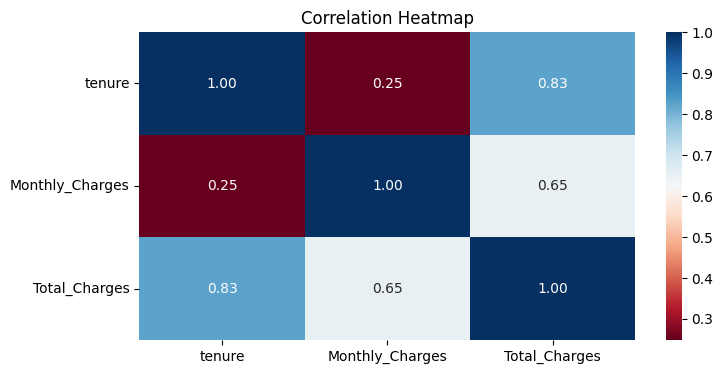

In [40]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "Monthly_Charges", "Total_Charges"]].corr(), annot=True, cmap="RdBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



*   tenure & Total_Charges is highly correlated
*   Monthly_Charges & Total_Charges is also correlated but tenure is most effective factor which means that keeping customer as long as could as customers in the company is more important than trying to sell them expensive services





2.   Categorical Features







In [41]:
df.columns

Index(['gender', 'Senior_Citizen ', 'Is_Married', 'Dependents', 'tenure',
       'Phone_Service', 'Dual', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

In [45]:
categorical_columns = df.select_dtypes(include="object").columns.to_list()
categorical_columns

['gender',
 'Is_Married',
 'Dependents',
 'Phone_Service',
 'Dual',
 'Internet_Service',
 'Online_Security',
 'Online_Backup',
 'Device_Protection',
 'Tech_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Contract',
 'Paperless_Billing',
 'Payment_Method',
 'Churn']

In [46]:
categorical_columns = ["Senior_Citizen "] + categorical_columns
categorical_columns

['Senior_Citizen ',
 'gender',
 'Is_Married',
 'Dependents',
 'Phone_Service',
 'Dual',
 'Internet_Service',
 'Online_Security',
 'Online_Backup',
 'Device_Protection',
 'Tech_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Contract',
 'Paperless_Billing',
 'Payment_Method',
 'Churn']

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


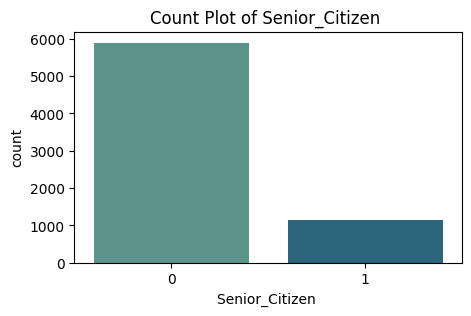

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


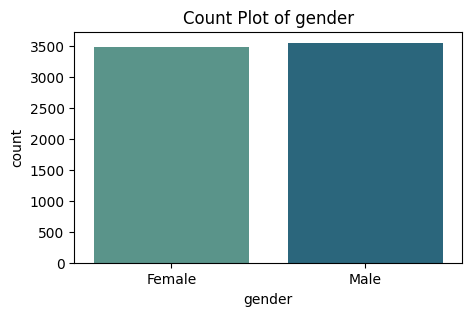

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


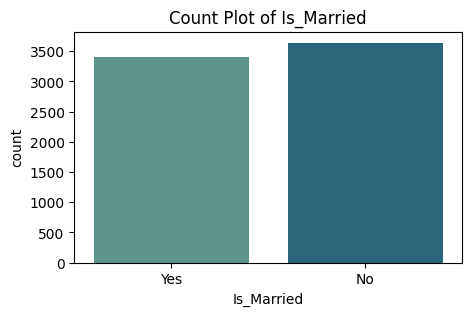

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


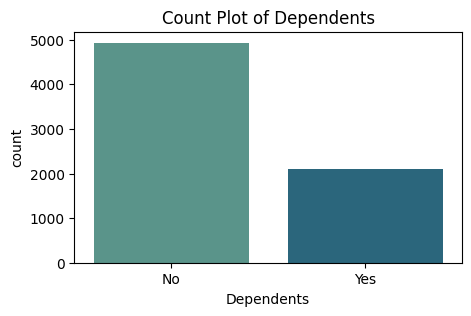

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


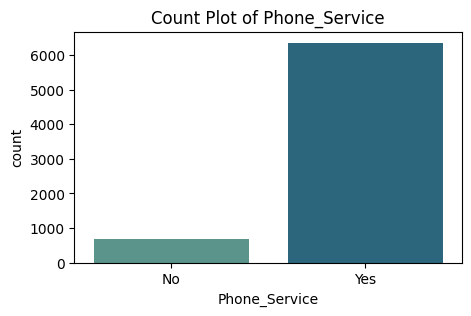

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


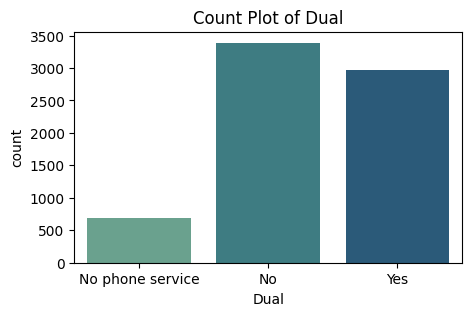

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


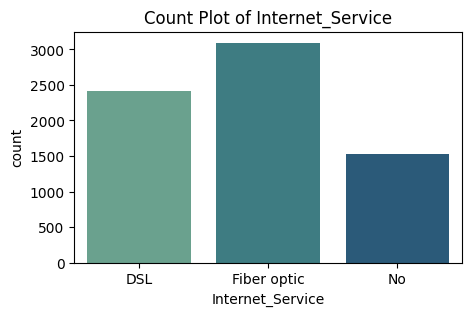

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


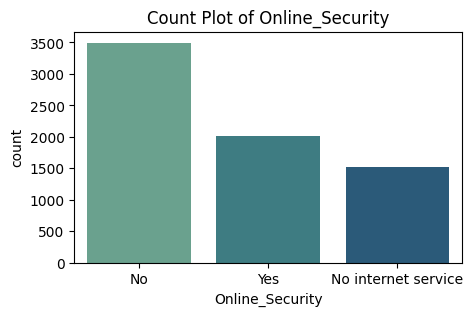

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


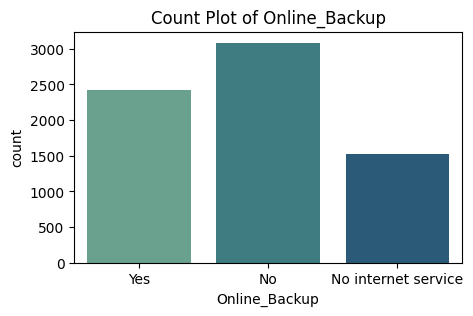

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


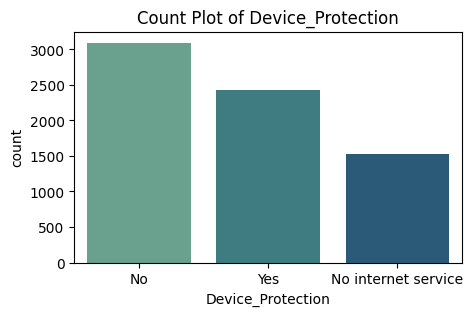

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


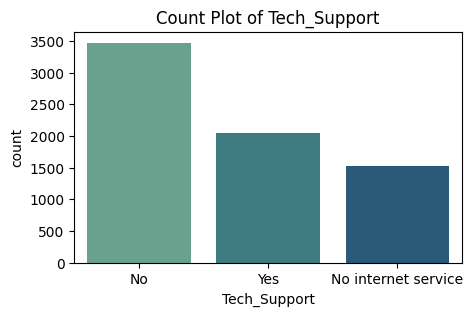

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


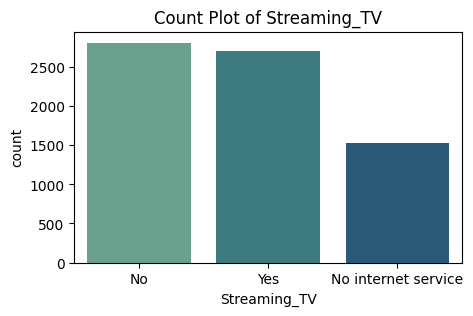

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


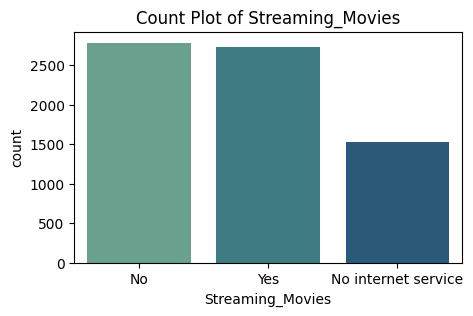

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


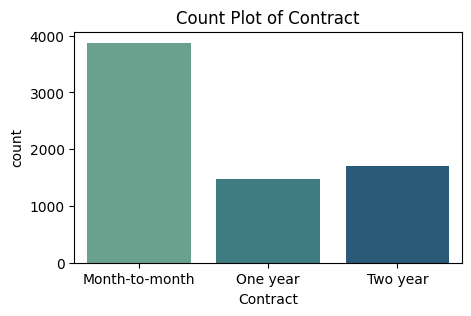

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


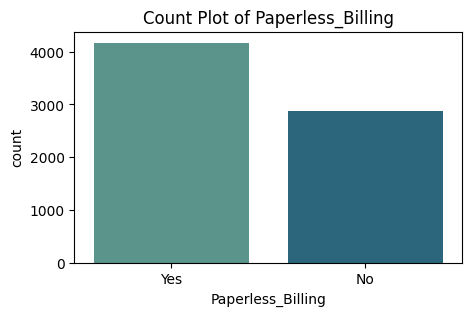

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


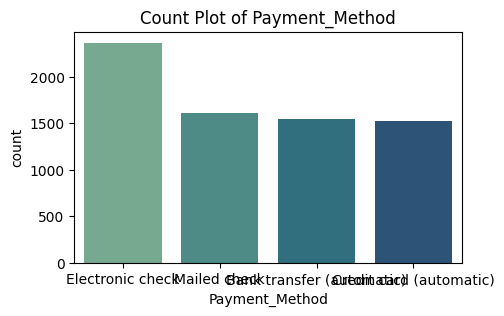

/tmp/ipykernel_15630/855913604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='crest')


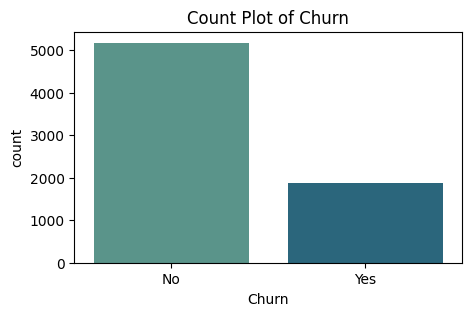

In [48]:
for col in categorical_columns :
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col], palette='crest')
  plt.title(f"Count Plot of {col}")
  plt.show()

**Data Preprocessing**

In [49]:
df.head()

,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
#lable encoding of Churn column
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

/tmp/ipykernel_15630/651277795.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})


In [51]:
df.head()

,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [53]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [54]:
categorical_columns = df.select_dtypes(include="object").columns

In [55]:
print(categorical_columns)

Index(['gender', 'Is_Married', 'Dependents', 'Phone_Service', 'Dual',
       'Internet_Service', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Contract', 'Paperless_Billing', 'Payment_Method'],
      dtype='object')


In [56]:
# initialize a dictionary to save the encoders
encoders = {}

# label encoding and store the encoders
for column in categorical_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)


In [57]:
encoders

{'gender': LabelEncoder(),
 'Is_Married': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'Phone_Service': LabelEncoder(),
 'Dual': LabelEncoder(),
 'Internet_Service': LabelEncoder(),
 'Online_Security': LabelEncoder(),
 'Online_Backup': LabelEncoder(),
 'Device_Protection': LabelEncoder(),
 'Tech_Support': LabelEncoder(),
 'Streaming_TV': LabelEncoder(),
 'Streaming_Movies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'Paperless_Billing': LabelEncoder(),
 'Payment_Method': LabelEncoder()}

In [75]:
df.head()

,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1




*   Later if we will build a prediction model with new or unknown data that has the same kind of categorical columns strings we can use this encoders dictionary
*   We can try with no lable encoding but the DataFrame will be very large
*   Lable encoding is suffecient for XGBoost





**Train-test-split**

In [60]:
X = df.drop(columns=["Churn"])
Y = df["Churn"]

In [65]:
#Split by 20% test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [66]:
print(y_train.shape)

(5634,)


In [67]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


**Fixing the Imbalance**



In [71]:
#Synthetic Minority Oversampling Technique (SMOTE)
smote = SMOTE(random_state=42)

In [76]:
#Show missing values
print(X_train.isnull().sum())

gender                0
Senior_Citizen        0
Is_Married            0
Dependents            0
tenure                0
Phone_Service         0
Dual                  0
Internet_Service      0
Online_Security       0
Online_Backup         0
Device_Protection     0
Tech_Support          0
Streaming_TV          0
Streaming_Movies      0
Contract              0
Paperless_Billing     0
Payment_Method        0
Monthly_Charges       0
Total_Charges        10
dtype: int64


In [77]:
# Drop the 10 missing values in Total_Charges column
X_train = X_train.dropna()
y_train = y_train[X_train.index]   # Keep y_train aligned with the new X_train

In [78]:
print(X_train.isnull().sum())

gender               0
Senior_Citizen       0
Is_Married           0
Dependents           0
tenure               0
Phone_Service        0
Dual                 0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
dtype: int64


In [80]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [84]:
print(y_train_smote.shape)

(8256,)


In [85]:
print(y_train_smote.value_counts())

Churn
0    4128
1    4128
Name: count, dtype: int64


**Training The Model**

In [86]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [88]:
# dictionary to store the cross validation results
cv_scores = {}

for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  # 5 fold cross validation for each model
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("*"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.79
**********************************************************************
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.84
**********************************************************************
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.83
**********************************************************************


In [89]:
cv_scores

{'Decision Tree': array([0.69552058, 0.71714113, 0.8322229 , 0.83525136, 0.84494246]),
 'Random Forest': array([0.73849879, 0.76256814, 0.90308904, 0.88976378, 0.89521502]),
 'XGBoost': array([0.71186441, 0.76438522, 0.90066626, 0.89460933, 0.8976378 ])}

In [91]:
random_forest = RandomForestClassifier(random_state=42)

In [92]:
random_forest.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

**Model Evaluation**

Accuracy Score:
 0.7757274662881476


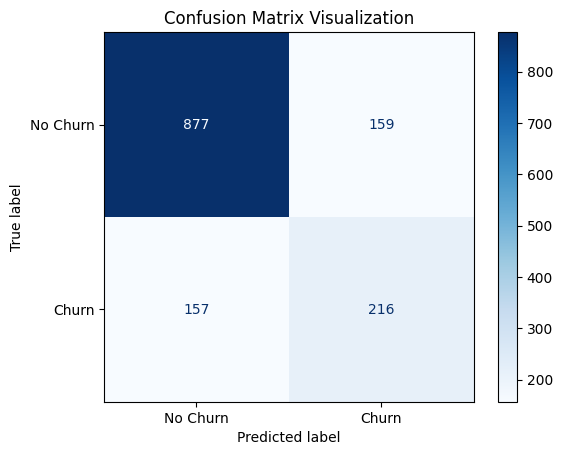

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [99]:
y_test_pred = random_forest.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
# print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred,
                                        display_labels=['No Churn', 'Churn'],
                                        cmap='Blues')
plt.title('Confusion Matrix Visualization')
plt.show()
print("Classification Report:\n", classification_report(y_test, y_test_pred))

In [103]:
# save the trained model for future use
model_data = {"model": random_forest, "features_names": X.columns.tolist()} # tolist() -> sending values with feature names


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

**Inference**

In [104]:
# Load the model
with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [106]:
print(feature_names)

['gender', 'Senior_Citizen ', 'Is_Married', 'Dependents', 'tenure', 'Phone_Service', 'Dual', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges']


In [110]:
input_data = {
    'gender': 'Female',
    'Senior_Citizen ': 0,
    'Is_Married': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'Phone_Service': 'No',
    'Dual': 'No phone service',
    'Internet_Service': 'DSL',
    'Online_Security': 'No',
    'Online_Backup': 'Yes',
    'Device_Protection': 'No',
    'Tech_Support': 'No',
    'Streaming_TV': 'No',
    'Streaming_Movies': 'No',
    'Contract': 'Month-to-month',
    'Paperless_Billing': 'Yes',
    'Payment_Method': 'Electronic check',
    'Monthly_Charges': 29.85,
    'Total_Charges': 29.85
}


input_data_df = pd.DataFrame([input_data])

# Load encoders
with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical features using the saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)


print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

[0]
Prediction: No Churn
Prediciton Probability: [[0.67 0.33]]
